In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Ecommerce_data (1).csv')
df.head()

,customer_id,customer_first_name,customer_last_name,category_name,product_name,customer_segment,customer_city,customer_state,customer_country,customer_region,...,order_date,order_id,ship_date,shipping_type,days_for_shipment_scheduled,days_for_shipment_real,order_item_discount,sales_per_order,order_quantity,profit_per_order
0,C_ID_45866,Mary,Fuller,Office Supplies,Xerox 1913,Corporate,New Rochelle,New York,United States,East,...,11/5/2022,O_ID_3001072,11/7/2022,Second Class,2,2,35.0,500.0,5,223.199997
1,C_ID_44932,Alan,Edelman,Office Supplies,#6 3/4 Gummed Flap White Envelopes,Corporate,Houston,Texas,United States,Central,...,20-06-2022,O_ID_3009170,23-06-2022,Second Class,2,3,85.0,500.0,5,199.199997
2,C_ID_70880,Mary,Gayman,Office Supplies,Belkin 8 Outlet Surge Protector,Consumer,Louisville,Kentucky,United States,South,...,25-06-2022,O_ID_3047567,30-06-2022,Standard Class,4,5,75.0,44.0,5,195.500000
3,C_ID_33157,Raymond,Eason,Office Supplies,GBC VeloBinder Manual Binding System,Corporate,Chicago,Illinois,United States,Central,...,10/6/2022,O_ID_3060575,10/10/2022,Second Class,2,4,60.0,254.0,1,220.000000
4,C_ID_58303,Mary,Gonzalez,Furniture,Eldon Pizzaz Desk Accessories,Home Office,Philadelphia,Pennsylvania,United States,East,...,2/5/2022,O_ID_3064311,8/1/2022,First Class,1,2,125.0,500.0,1,97.500000


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113270 entries, 0 to 113269
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_id                  113270 non-null  object 
 1   customer_first_name          113270 non-null  object 
 2   customer_last_name           113270 non-null  object 
 3   category_name                113270 non-null  object 
 4   product_name                 113270 non-null  object 
 5   customer_segment             113270 non-null  object 
 6   customer_city                113270 non-null  object 
 7   customer_state               113270 non-null  object 
 8   customer_country             113270 non-null  object 
 9   customer_region              113270 non-null  object 
 10  delivery_status              113270 non-null  object 
 11  order_date                   113270 non-null  object 
 12  order_id                     113270 n

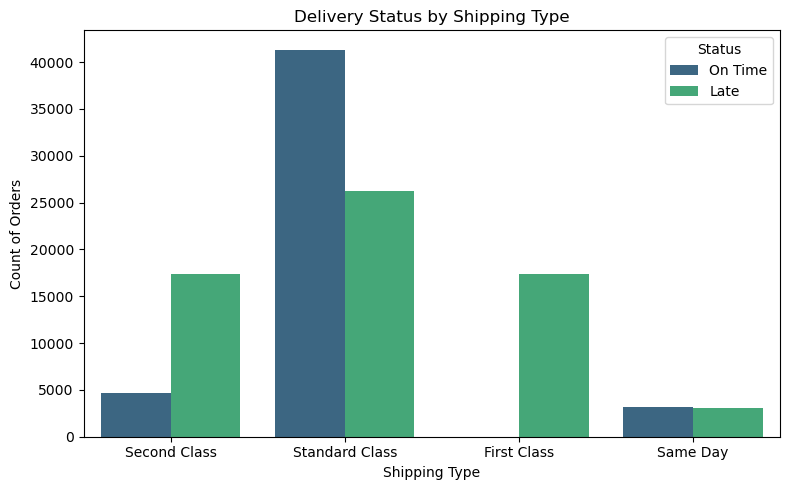

In [4]:
# 2. Let's inspect basic dataset information
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 3. Create the Target Variable: Actual Delivery Status
# If real shipment days > scheduled shipment days, it is "Late" (1), otherwise "On Time" (0)
df['delivery_status'] = np.where(
    df['days_for_shipment_real'] > df['days_for_shipment_scheduled'], 
    1, 
    0
)

# 4. Check class distribution (Is our dataset imbalanced?)
status_counts = df['delivery_status'].value_counts()
status_pct = df['delivery_status'].value_counts(normalize=True) * 100

print("\n--- Target Variable Distribution ---")
for idx in status_counts.index:
    label = "Late (1)" if idx == 1 else "On Time (0)"
    print(f"{label}: {status_counts[idx]} rows ({status_pct[idx]:.2f}%)")

# 5. Quick Visualization of Delays by Shipping Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='shipping_type', hue='delivery_status', palette='viridis')
plt.title('Delivery Status by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Count of Orders')
plt.legend(title='Status', labels=['On Time', 'Late'])
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# 1. Define Features (X) and Target (y)
# We exclude IDs, names, dates, and actual shipment duration to prevent leakage.
features = [
    'shipping_type', 
    'customer_segment', 
    'customer_region', 
    'category_name',
    'days_for_shipment_scheduled', 
    'order_item_discount', 
    'sales_per_order', 
    'order_quantity', 
    'profit_per_order'
]

X = df[features]
y = df['delivery_status']

# 2. Identify numerical and categorical columns
categorical_cols = ['shipping_type', 'customer_segment', 'customer_region', 'category_name']
numerical_cols = ['days_for_shipment_scheduled', 'order_item_discount', 'sales_per_order', 'order_quantity', 'profit_per_order']

# 3. Create Preprocessing Pipelines
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 4. Split data into Train and Test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (90616, 9)
Testing set size: (22654, 9)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# 1. Create a complete pipeline: Preprocessing + Model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# 2. Train (Fit) the pipeline on the training data
print("Training the Random Forest model... (this may take a few moments)")
model_pipeline.fit(X_train, y_train)
print("Model training complete!")

# 3. Predict on the test set
y_pred = model_pipeline.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

# 5. Save the trained pipeline and features for our Streamlit app
# Saving both the pipeline and the unique categorical categories to help build Streamlit dropdowns easily
model_data = {
    'pipeline': model_pipeline,
    'features': features,
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols,
    'categories': {col: df[col].unique().tolist() for col in categorical_cols}
}

joblib.dump(model_data, 'delivery_model_pipeline.pkl')
print("\nPipeline saved successfully as 'delivery_model_pipeline.pkl'!")

Training the Random Forest model... (this may take a few moments)
Model training complete!

Accuracy Score: 0.6616

--- Classification Report ---
              precision    recall  f1-score   support

     On Time       0.60      0.64      0.62      9841
        Late       0.71      0.68      0.69     12813

    accuracy                           0.66     22654
   macro avg       0.66      0.66      0.66     22654
weighted avg       0.66      0.66      0.66     22654


Pipeline saved successfully as 'delivery_model_pipeline.pkl'!
